# 최종 정제 데이터셋 탐색적 데이터 분석 (EDA)

이 노트북은 전처리가 완료된 `최종정제_적응적_명사포함_v2.csv` 파일의 통계적 특성과 주요 단어 분포를 분석합니다.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.util import ngrams
import os

# 폰트 설정 (Windows 기준 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

input_path = os.path.join("..", "data", "processed", "최종정제_v2.csv")
df = pd.read_csv(input_path, encoding='utf-8-sig')
df['final_text'] = df['final_text'].fillna("")
df['token_list'] = df['final_text'].apply(lambda x: x.split())
df['token_count'] = df['token_list'].apply(len)

print(f"전체 댓글 수: {len(df):,}개")

전체 댓글 수: 55,267개


## 1. 기본 통계 분석

In [2]:
all_tokens = [token for sublist in df['token_list'] for token in sublist]
total_tokens = len(all_tokens)
unique_tokens = len(set(all_tokens))
avg_tokens = df['token_count'].mean()

print(f"전체 토큰 수: {total_tokens:,}개")
print(f"고유 토큰 수: {unique_tokens:,}개")
print(f"댓글당 평균 토큰 수: {avg_tokens:.2f}개")

전체 토큰 수: 691,548개
고유 토큰 수: 4,096개
댓글당 평균 토큰 수: 12.51개


## 2. 단어 빈도 시각화

c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


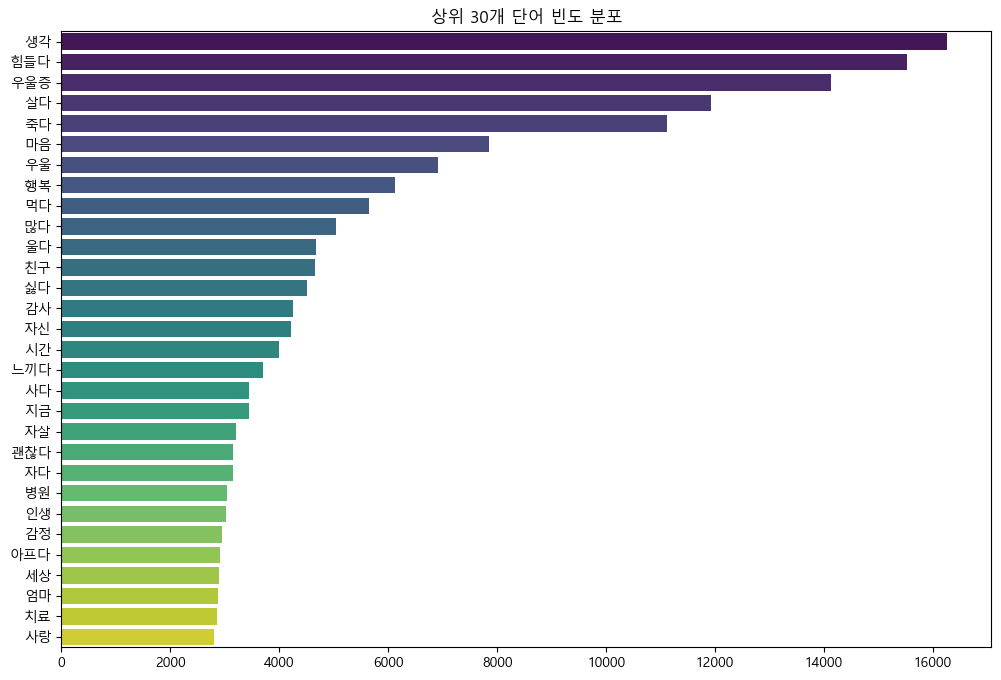

In [3]:
token_counts = Counter(all_tokens)
top_30 = token_counts.most_common(30)

plt.figure(figsize=(12, 8))
words, counts = zip(*top_30)
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('상위 30개 단어 빈도 분포')
plt.show()

## 3. 댓글 길이 분포

c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


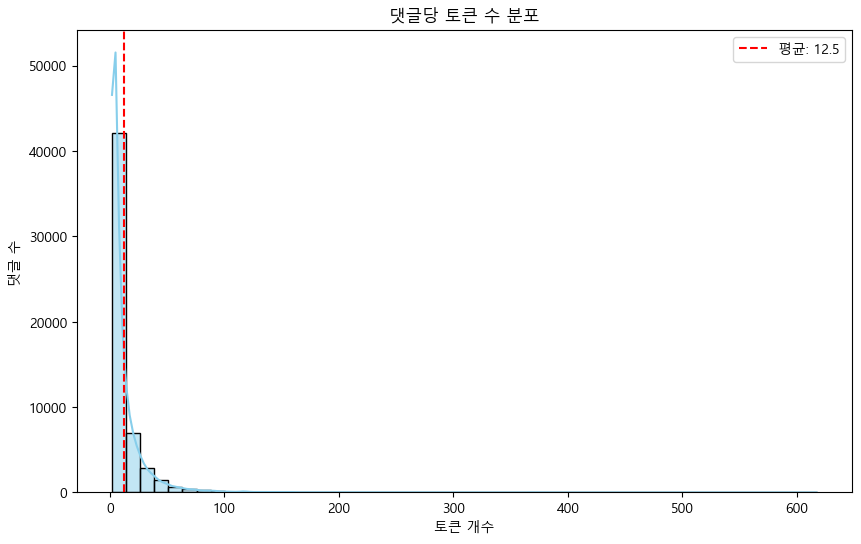

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['token_count'], bins=50, kde=True, color='skyblue')
plt.title('댓글당 토큰 수 분포')
plt.xlabel('토큰 개수')
plt.ylabel('댓글 수')
plt.axvline(avg_tokens, color='red', linestyle='--', label=f'평균: {avg_tokens:.1f}')
plt.legend()
plt.show()

## 4. N-gram 분석 (Bigrams)

In [5]:
bi_grams = list(ngrams(all_tokens, 2))
bigram_counts = Counter(bi_grams)
top_20_bigrams = bigram_counts.most_common(20)

print("=== 주요 단어 조합 Top 20 ===")
for i, (bg, count) in enumerate(top_20_bigrams):
    print(f"{i+1}. {' '.join(bg)}: {count:,}")

=== 주요 단어 조합 Top 20 ===
1. 죽다 생각: 1,126
2. 죽다 죽다: 1,099
3. 힘들다 힘들다: 938
4. 우울증 걸리다: 858
5. 죽다 살다: 644
6. 살다 싫다: 635
7. 자살 생각: 562
8. 살다 살다: 538
9. 생각 생각: 473
10. 살다 죽다: 463
11. 울다 울다: 449
12. 공황 장애: 444
13. 신경 쓰다: 444
14. 힘들다 죽다: 439
15. 살다 생각: 431
16. 우울증 심하다: 428
17. 생각 우울증: 423
18. 생각 살다: 417
19. 마음 아프다: 406
20. 생각 죽다: 404
